In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
import ast
import torch
from tqdm import tqdm
tqdm.pandas(desc="Processing Rows")
import os
import time
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 
import gc
gc.collect()
import torch
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# torch.cuda.empty_cache()

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# !ls /common/data/models/

In [3]:

balanced_sample=pd.read_csv("balanced_sample.csv")

In [4]:
# Extreme vs Severe
# Extreme vs Moderate
# Extreme vs Minor
# Severe vs Moderate
# Severe vs Minor
# Moderate vs Minor

In [5]:
choices = ["A", "B"]

template = """Which emergency message indicates the greater threat to life or property?

Message A:
{}

Message B:
{}

Answer only A or B."""
def make_pairs(df, p1, p2, n=160, seed=42):
    pair_df = pd.DataFrame()

    pair_df[p1] = (
        df[df["severity"] == p1]
        .sample(n, random_state=seed)["description"]
        .reset_index(drop=True)
    )

    pair_df[p2] = (
        df[df["severity"] == p2]
        .sample(n, random_state=seed+1)["description"]
        .reset_index(drop=True)
    )

    return pair_df
    
def shuffle_pair(df, high_col, low_col, seed=42):
    out = df[[high_col, low_col]].copy()
    
    rng = np.random.default_rng(seed)
    swap = np.zeros(len(out), dtype=bool)
    swap[:len(out)//2] = True
    rng.shuffle(swap)
    
    out["A"] = np.where(swap, out[low_col], out[high_col])
    out["B"] = np.where(swap, out[high_col], out[low_col])
    out["answer"] = np.where(swap, "B", "A")
    
    return out[["A", "B", "answer"]]
    
def initalSetup(name):
    model_name = f"/common/data/models/{name}"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    choice_ids = {
        c: tokenizer(" " + c, add_special_tokens=False,
                     return_tensors="pt").input_ids[0]
        for c in choices
    }
    return name, model, tokenizer, choice_ids
    
def classify(msg_a, msg_b, model, tokenizer, choice_ids):
    messages = [{
        "role": "user",
        "content": template.format(msg_a, msg_b)
    }]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    pids = tokenizer(
        prompt,
        add_special_tokens=False,
        truncation=True,
        return_tensors="pt"
    ).input_ids[0]

    seqs = [torch.cat([pids, choice_ids[c]]) for c in choices]

    batch = torch.nn.utils.rnn.pad_sequence(
        seqs, batch_first=True,
        padding_value=tokenizer.pad_token_id
    ).to(model.device)

    lengths = torch.tensor([len(x) for x in seqs], device=model.device)
    mask = (
        torch.arange(batch.shape[1], device=model.device)[None, :]
        < lengths[:, None]
    ).long()

    with torch.inference_mode():
        logits = model(input_ids=batch, attention_mask=mask).logits

    scores = {}

    for i, c in enumerate(choices):
        ids = choice_ids[c].to(model.device)
        p = len(pids)

        lp = torch.log_softmax(
            logits[i, p-1:p+len(ids)-1], dim=-1
        )

        scores[c] = lp.gather(
            1, ids.unsqueeze(-1)
        ).sum().item()

    return max(scores, key=scores.get)




def evaluate_pairs(sample, model, tokenizer, choice_ids):
    sample = sample.copy()

    sample["prediction"] = [
        classify(a, b, model, tokenizer, choice_ids)
        for a, b in zip(sample["A"], sample["B"])
    ]

    sample["correct"] = sample["prediction"] == sample["answer"]
    results = pd.DataFrame.from_dict({
        "n": len(sample),
        "accuracy": accuracy_score(sample["answer"], sample["prediction"]),
        "precision": precision_score(sample["answer"], sample["prediction"], average="macro"),
        "recall": recall_score(sample["answer"], sample["prediction"], average="macro"),
        "f1": f1_score(sample["answer"], sample["prediction"], average="macro")
    }, orient="index", columns=["value"])
    return results

In [6]:
# small_names=["google--gemma-3-4b-it", "meta-llama--Llama-3.2-3B-Instruct", "microsoft--Phi-4-mini-instruct"]
pairs = [("Extreme" , "Severe"), ("Extreme", "Moderate"), ("Extreme" , "Minor"), ("Severe" , "Moderate"), ("Severe", "Minor"),  ("Moderate" , "Minor")]

large_names=["google--gemma-3-12b-it", "meta-llama--Llama-3.1-8B-Instruct", "microsoft--phi-4"]
full=[]
for name in large_names:
    print(name)
    name, model, tokenizer, choice_ids=initalSetup(name)
    dfs=[]
    for i in range(0, len(pairs)):
        pairs_df=make_pairs(balanced_sample, pairs[i][0], pairs[i][1])
        pairs_df=shuffle_pair(pairs_df, pairs[i][0], pairs[i][1], seed=44)
    
        
        results = evaluate_pairs(pairs_df, model, tokenizer, choice_ids)
        results.columns = [f"{name}_{pairs[i][0]}_vs_{pairs[i][1]}"]
        dfs.append(results)

        
    full.append(pd.concat(dfs, axis=1))
    del model, tokenizer, choice_ids
    torch.cuda.empty_cache()

full = pd.concat(full, axis=1)
full

google--gemma-3-12b-it


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 1065/1065 [00:02<00:00, 399.62it/s]


meta-llama--Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:01<00:00, 164.13it/s]


microsoft--phi-4


Loading weights: 100%|██████████| 243/243 [00:03<00:00, 74.68it/s]


,google--gemma-3-12b-it_Extreme_vs_Severe,google--gemma-3-12b-it_Extreme_vs_Moderate,google--gemma-3-12b-it_Extreme_vs_Minor,google--gemma-3-12b-it_Severe_vs_Moderate,google--gemma-3-12b-it_Severe_vs_Minor,google--gemma-3-12b-it_Moderate_vs_Minor,meta-llama--Llama-3.1-8B-Instruct_Extreme_vs_Severe,meta-llama--Llama-3.1-8B-Instruct_Extreme_vs_Moderate,meta-llama--Llama-3.1-8B-Instruct_Extreme_vs_Minor,meta-llama--Llama-3.1-8B-Instruct_Severe_vs_Moderate,meta-llama--Llama-3.1-8B-Instruct_Severe_vs_Minor,meta-llama--Llama-3.1-8B-Instruct_Moderate_vs_Minor,microsoft--phi-4_Extreme_vs_Severe,microsoft--phi-4_Extreme_vs_Moderate,microsoft--phi-4_Extreme_vs_Minor,microsoft--phi-4_Severe_vs_Moderate,microsoft--phi-4_Severe_vs_Minor,microsoft--phi-4_Moderate_vs_Minor
n,160.000000,160.000000,160.000000,160.000000,160.000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
accuracy,0.643750,0.868750,0.856250,0.906250,0.875,0.500000,0.618750,0.843750,0.812500,0.818750,0.762500,0.481250,0.637500,0.862500,0.787500,0.812500,0.800000,0.475000
precision,0.646520,0.868808,0.857647,0.907843,0.875,0.500000,0.621971,0.843804,0.815657,0.819199,0.762664,0.481247,0.648749,0.863409,0.802831,0.829164,0.820000,0.470909
recall,0.643750,0.868750,0.856250,0.906250,0.875,0.500000,0.618750,0.843750,0.812500,0.818750,0.762500,0.481250,0.637500,0.862500,0.787500,0.812500,0.800000,0.475000
f1,0.642058,0.868745,0.856109,0.906158,0.875,0.499922,0.616216,0.843744,0.812030,0.818686,0.762463,0.481230,0.630514,0.862414,0.784776,0.810097,0.796825,0.455870


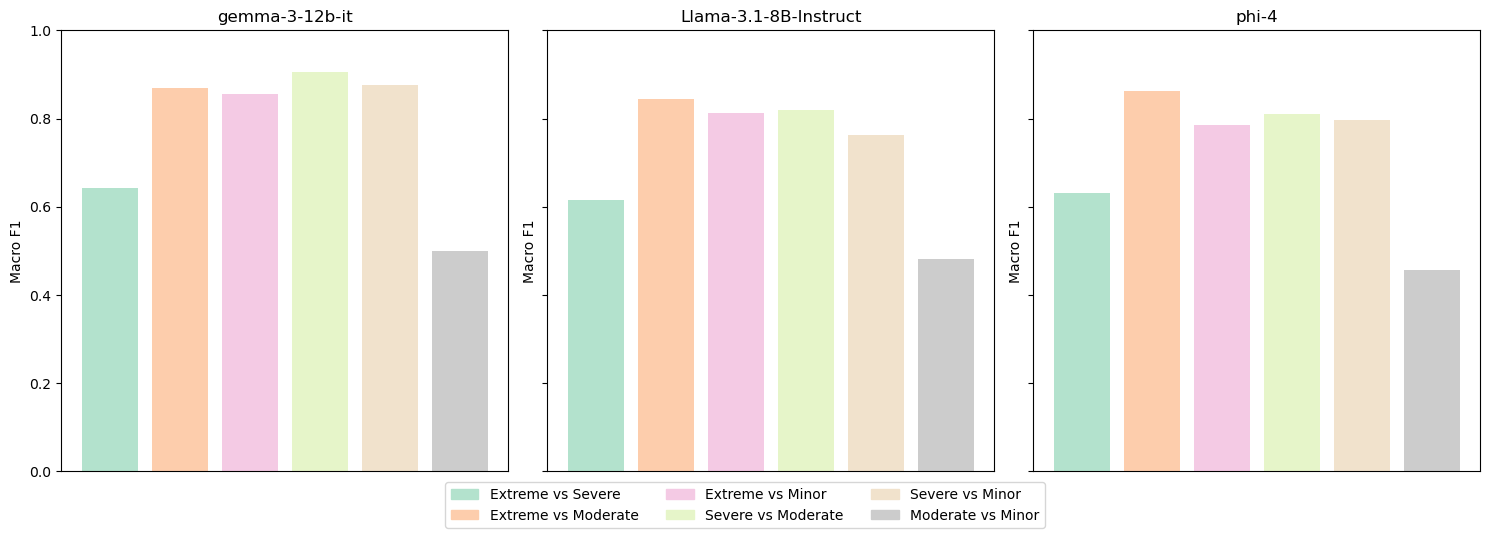

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = large_names   

pair_labels = [
    "Extreme vs Severe",
    "Extreme vs Moderate",
    "Extreme vs Minor",
    "Severe vs Moderate",
    "Severe vs Minor",
    "Moderate vs Minor"
]

colors = plt.cm.Pastel2(np.linspace(0, 1, 6))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, model in zip(axes, models):
    vals = [
        full.loc["f1", f"{model}_{p1}_vs_{p2}"]
        for p1, p2 in pairs
    ]

    ax.bar(range(6), vals, color=colors)
    ax.set_title(model.split("--")[-1])
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_ylabel("Macro F1")

handles = [
    plt.Rectangle((0,0), 1, 1, color=c)
    for c in colors
]

fig.legend(
    handles, pair_labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.show()